In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
e3_expr = pd.read_pickle("pydata/e3_expression_filtered.pkl")
tf_effect = pd.read_pickle("pydata/tfs_dependencies_filtered.pkl")
model = pd.read_pickle("pydata/model_data.pkl")

In [3]:
significant_cors = pd.read_pickle("pydata/tf_dependency_e3ls_expr_correlation_bylineage_fdr_significant.pkl")

In [4]:
significant_cors.head()

,lineage,TF,E3_ligase,p-val,corr,TF-class,fdr,log10q,name
14339,Biliary Tract,DMRT1,PDZRN3,5.360362e-06,0.678751,Positive,0.046343,1.334020,DMRT1-PDZRN3
14362,Biliary Tract,POU3F4,PDZRN3,7.373695e-08,0.760493,Positive,0.001039,2.983481,POU3F4-PDZRN3
14369,Biliary Tract,TP53,PDZRN3,3.209376e-08,0.773384,Positive,0.000603,3.219807,TP53-PDZRN3
27405,Biliary Tract,ZNF221,TRIM26,1.404946e-05,-0.655954,Positive,0.098961,1.004536,ZNF221-TRIM26
46539,Biliary Tract,DMRT1,KLHL10,6.492342e-07,0.722565,Positive,0.007317,2.135675,DMRT1-KLHL10


In [5]:
significant_cors.loc[significant_cors['lineage'] == "Lymphoid"].sort_values(by = ["fdr", "corr"])

,lineage,TF,E3_ligase,p-val,corr,TF-class,fdr,log10q,name
659176,Lymphoid,MYB,RAG1,3.787275e-12,-0.637376,Negative,1.236219e-07,6.907905,MYB-RAG1
648106,Lymphoid,EBF1,DTX1,3.973065e-12,-0.636903,Negative,1.236219e-07,6.907905,EBF1-DTX1
679503,Lymphoid,POU2AF1,ZNRF1,1.144818e-10,0.601532,Negative,2.374733e-06,5.624385,POU2AF1-ZNRF1
671220,Lymphoid,EBF1,TRIM22,5.996683e-10,-0.582358,Negative,9.329340e-06,5.030149,EBF1-TRIM22
657525,Lymphoid,MYB,PELI2,8.871726e-10,-0.577634,Negative,1.104175e-05,4.956962,MYB-PELI2
...,...,...,...,...,...,...,...,...,...
680068,Lymphoid,ZNF391,ABTB1,1.623107e-04,0.377518,Positive,9.182359e-02,1.037046,ZNF391-ABTB1
647017,Lymphoid,SP4,CBL,1.643564e-04,-0.377228,Positive,9.214322e-02,1.035537,SP4-CBL
675940,Lymphoid,MYB,TRIM73,1.707593e-04,-0.376343,Negative,9.382172e-02,1.027697,MYB-TRIM73
664707,Lymphoid,ZNF543,RNF182,1.718733e-04,-0.376193,Positive,9.382172e-02,1.027697,ZNF543-RNF182


In [6]:
def get_scatterplot_bylineage(tf, e3_ligase, lineage, stat_pos):
    lin_models = model.loc[model["OncotreeLineage"] == lineage, "ModelID"]
    lin_e3_expr = e3_expr.loc[e3_expr.index.isin(lin_models), e3_ligase]
    lin_tf_effect = tf_effect.loc[tf_effect.index.isin(lin_models), tf]
    corr_q = significant_cors.loc[(significant_cors['lineage'] == lineage) &
                                   (significant_cors["TF"] == tf) &
                                   (significant_cors["E3_ligase"] == e3_ligase), ["corr", 'fdr']].to_numpy()[0]
    
    plt.figure(figsize=(8,5))
    ax = plt.subplot(111)
    m, b = np.polyfit(lin_tf_effect, lin_e3_expr, 1)
    sns.scatterplot(x=lin_tf_effect, y = lin_e3_expr)
    ax.plot(lin_tf_effect, m*lin_tf_effect + b, color='grey', linewidth=1)
    if stat_pos == "top":
        ax.text(-0.2, max(lin_e3_expr)-0.25, f"r = {round(corr_q[0], 5)}", fontsize = 12)
        ax.text(-0.2, max(lin_e3_expr)-0.65, f"q-val = {corr_q[1]:.3e}", fontsize = 12)
    elif stat_pos == "bottom":
        ax.text(max(lin_tf_effect)-0.4, 0.65, f"r = {round(corr_q[0], 5)}", fontsize = 12)
        ax.text(max(lin_tf_effect)-0.4, 0.25, f"q-val = {corr_q[1]:.3e}", fontsize = 12) 
    ax.spines[['right', 'top']].set_visible(False)
    plt.ylim((0, max(lin_e3_expr)+0.1))
    plt.xlabel(f"TF gene effect", fontdict={"fontsize":13})
    plt.xticks(size = 13)
    plt.yticks(size = 13)
    plt.ylabel(f"E3 ligase expression", fontdict={"fontsize":13})
    plt.title(f"{tf} gene effect - {e3_ligase} expression in \n{lineage} cell lines", 
              fontdict={"fontsize": 18})
    

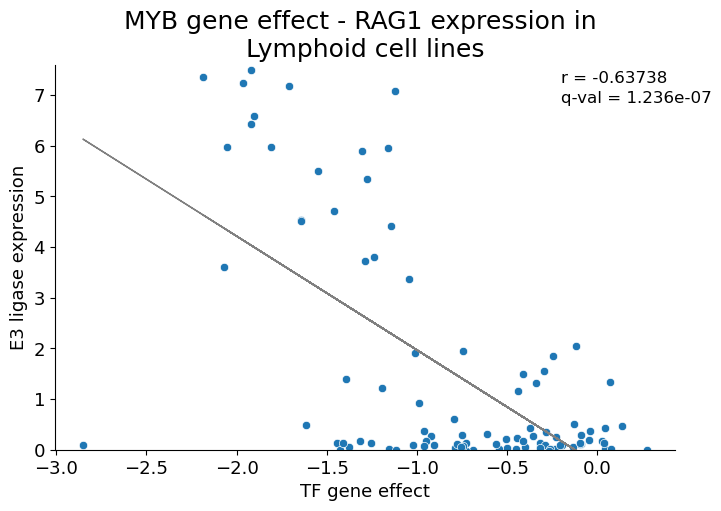

In [7]:
get_scatterplot_bylineage("MYB", "RAG1", "Lymphoid", "top")

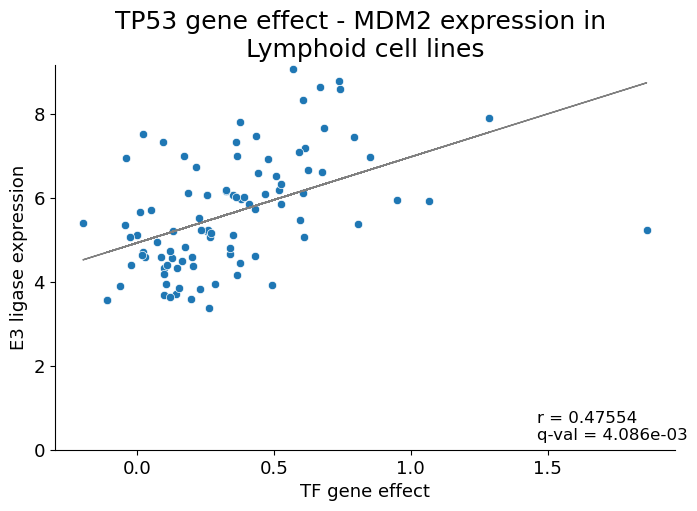

In [8]:
get_scatterplot_bylineage("TP53", "MDM2", "Lymphoid", "bottom")